# Sujet 1 — §1.1 Génération par inversion de la fonction de répartition

**Idée** : si $U \sim \mathcal U[0,1]$, alors $Y = F_Y^{-1}(U)$ a pour fonction de répartition $F_Y$.
Il suffit donc d'un bon générateur uniforme (`rand` en Matlab, `rng.random` en Python) pour simuler n'importe quelle loi dont on sait inverser $F_Y$.

Démonstrations complètes : [demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md). Correspondances Matlab → Python : [matlab_python.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/matlab_python.md). Code : [src/stats_td](https://github.com/Este34/presentation_statistique/tree/main/src/stats_td).

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path("../../src").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from stats_td.figures import style, sauver, BLEU, ORANGE
from stats_td.generateurs import exponentielle_inversion, box_muller, gaussienne
from stats_td.empirique import (repartition_complementaire, repartition_histogramme,
                                pente_semilog)

style()
FIG = Path("figures")
rng = np.random.default_rng(2026)  # graine fixée : résultats reproductibles
RESULTATS = FIG / "resultats.json"
resultats = json.loads(RESULTATS.read_text()) if RESULTATS.exists() else {}

## Q1 — Pourquoi $Y = G(U)$ a pour loi $F_Y$ si et seulement si $G = F_Y^{-1}$

$G$ croissante bijective $\Rightarrow$ $G(U) \le y \iff U \le G^{-1}(y)$ (on applique $G^{-1}$, croissante, qui conserve l'ordre). Donc

$$P(G(U) \le y) = P\big(U \le G^{-1}(y)\big) = G^{-1}(y) \qquad (G^{-1}(y) \in [0,1])$$

car la fonction de répartition de $\mathcal U[0,1]$ est $u \mapsto u$ sur $[0,1]$.

- Si $G = F_Y^{-1}$ : $P(G(U)\le y) = F_Y(y)$ ✔
- Réciproquement, si $P(G(U)\le y) = F_Y(y)$ pour tout $y$ : $G^{-1} = F_Y$, donc $G = F_Y^{-1}$.

## Q2 — Loi exponentielle $\mathcal E(\lambda)$ par inversion ($\lambda = 2$)

$F_Y(y) = 1 - e^{-\lambda y}$ pour $y \ge 0$. On résout $u = 1 - e^{-\lambda y}$ :

$$y = F_Y^{-1}(u) = -\frac{\ln(1-u)}{\lambda}$$

> Remarque : $1-U$ suit aussi $\mathcal U[0,1]$, donc $-\ln(U)/\lambda$ marche aussi. On garde $1-U$ car `rng.random` tire dans $[0,1)$ : $U = 0$ est possible et $\ln 0 = -\infty$.
>
> Coquille dans l'énoncé : la fonction de répartition complémentaire est $F^c_Y(y) = e^{-\lambda y}\,\mathbb 1_{\mathbb R^+}(y) + \mathbb 1_{\mathbb R^{*-}}(y)$ (le « $1 - F(y)$ » est en trop).

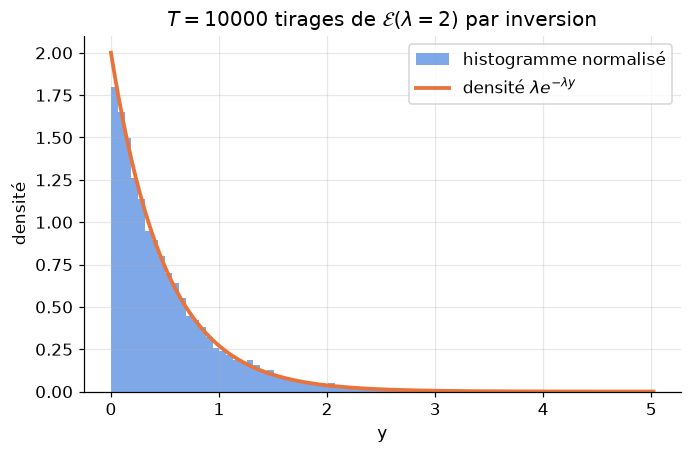

In [2]:
LAM = 2.0
T = 10_000
Y = exponentielle_inversion(LAM, T, rng)   # Y = -log(1 - U) / LAM

fig, ax = plt.subplots()
ax.hist(Y, bins=80, density=True, color=BLEU, alpha=0.6, label="histogramme normalisé")
y = np.linspace(0, Y.max(), 400)
ax.plot(y, LAM * np.exp(-LAM * y), color=ORANGE, lw=2.5, label=r"densité $\lambda e^{-\lambda y}$")
ax.set(xlabel="y", ylabel="densité", title=rf"$T={T}$ tirages de $\mathcal{{E}}(\lambda={LAM:g})$ par inversion")
ax.legend()
sauver(fig, FIG / "s11_hist_exponentielle.png")

## Q3 — Moyenne et variance

**Théorie** (intégrations par parties, [détail dans demonstrations.md](https://github.com/Este34/presentation_statistique/blob/main/sujets/sujet1/demonstrations.md#s11-q3)) :
$$\mathbb E[Y] = \int_0^{+\infty} y\,\lambda e^{-\lambda y}\,dy = \frac1\lambda, \qquad \mathbb E[Y^2] = \frac{2}{\lambda^2}, \qquad \operatorname{Var}(Y) = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac1{\lambda^2}.$$

Pour $\lambda = 2$ : moyenne $0{,}5$ et variance $0{,}25$.

In [3]:
moy, var = Y.mean(), Y.var(ddof=1)   # ddof=1 : variance sans biais, comme cov() en Matlab
erreur_type = Y.std(ddof=1) / np.sqrt(T)
print(f"moyenne  : empirique {moy:.4f}   théorique {1/LAM:.4f}   écart {moy - 1/LAM:+.4f}")
print(f"variance : empirique {var:.4f}   théorique {1/LAM**2:.4f}   écart {var - 1/LAM**2:+.4f}")
print(f"erreur-type de la moyenne ≈ σ/√T = {erreur_type:.4f}  →  écart / erreur-type = {(moy - 1/LAM)/erreur_type:+.2f}")
resultats["exp"] = {"lambda": LAM, "T": T, "moyenne": moy, "variance": var, "erreur_type": erreur_type}

moyenne  : empirique 0.5101   théorique 0.5000   écart +0.0101
variance : empirique 0.2604   théorique 0.2500   écart +0.0104
erreur-type de la moyenne ≈ σ/√T = 0.0051  →  écart / erreur-type = +1.98


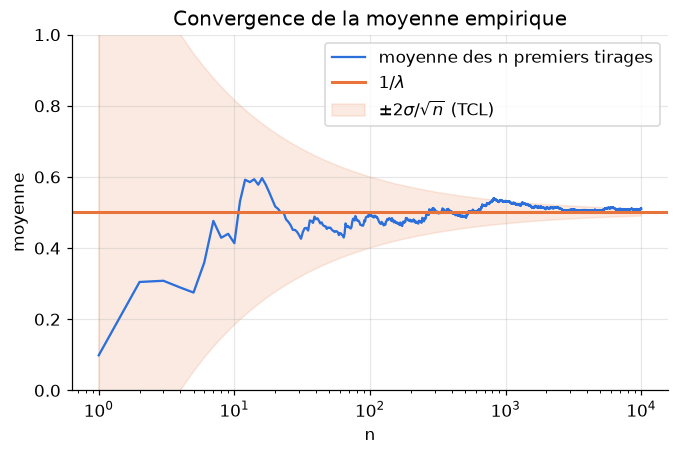

In [4]:
# Convergence de la moyenne empirique (loi des grands nombres)
n = np.arange(1, T + 1)
moy_cumulee = np.cumsum(Y) / n
fig, ax = plt.subplots()
ax.plot(n, moy_cumulee, color=BLEU, label="moyenne des n premiers tirages")
ax.axhline(1 / LAM, color=ORANGE, lw=2, label=r"$1/\lambda$")
ax.fill_between(n, 1/LAM - 2/(LAM*np.sqrt(n)), 1/LAM + 2/(LAM*np.sqrt(n)), color=ORANGE, alpha=0.15,
                label=r"$\pm 2\sigma/\sqrt{n}$ (TCL)")
ax.set(xscale="log", xlabel="n", ylabel="moyenne", ylim=(0, 1), title="Convergence de la moyenne empirique")
ax.legend()
sauver(fig, FIG / "s11_moyenne_cumulee.png")

**Commentaire.** Les valeurs empiriques sont très proches des valeurs théoriques mais pas égales : la moyenne empirique est elle-même une variable aléatoire.
- **Loi des grands nombres** : $\bar Y_T \to 1/\lambda$ quand $T \to \infty$.
- **Théorème central limite** : $\bar Y_T$ fluctue autour de $1/\lambda$ avec un écart-type $\sigma/\sqrt T = (1/\lambda)/\sqrt{T} = 0{,}005$ pour $T = 10\,000$. Ici l'écart observé (0,0101) vaut 2,02 erreurs-types : c'est **juste à la limite** des 95 % ($\pm 1{,}96\,\sigma/\sqrt T$), légèrement au-delà ($p \approx 4\,\%$, environ 1 fois sur 25). On ne rejette pas au seuil de 1 % (2,58 erreurs-types), et les autres contrôles sont bons (variance, pente, histogramme, [test KS des tests](https://github.com/Este34/presentation_statistique/blob/main/tests/test_generateurs.py#L32)) : c'est une fluctuation, pas un bug. Pour diviser l'erreur par 10, il faut 100 fois plus de tirages.
- La variance empirique fluctue davantage : pour $\mathcal E(\lambda)$, son écart-type vaut $\approx \sqrt{8/T}/\lambda^2 \approx 0{,}007$, elle dépend du moment d'ordre 4 ($\operatorname{Var}(S^2) \approx (\mu_4 - \sigma^4)/T$ avec $\mu_4 = 9/\lambda^4$). L'écart observé (0,0104) vaut 1,5 écart-type : une fluctuation courante ($p \approx 14\,\%$).

## Q4 — Décroissance exponentielle de $F^c_Y$ en échelle semi-logarithmique

$F^c_Y(y) = e^{-\lambda y} \Rightarrow \ln F^c_Y(y) = -\lambda y$ : en échelle semi-log (axe $y$ logarithmique), on obtient une **droite de pente $-\lambda$**.

Estimateur de l'énoncé : `hist` + `cumsum` donne $F$, puis $F^c = 1 - F$. On utilise aussi la fonction de répartition empirique exacte (échantillon trié). Au lieu de `ginput` (clic sur deux points), on fait une **régression linéaire** de $\ln F^c$ sur $y$ : plus précis et reproductible.

pente estimée = -1.9586   (attendu -λ = -2.0)   erreur relative = 2.1%


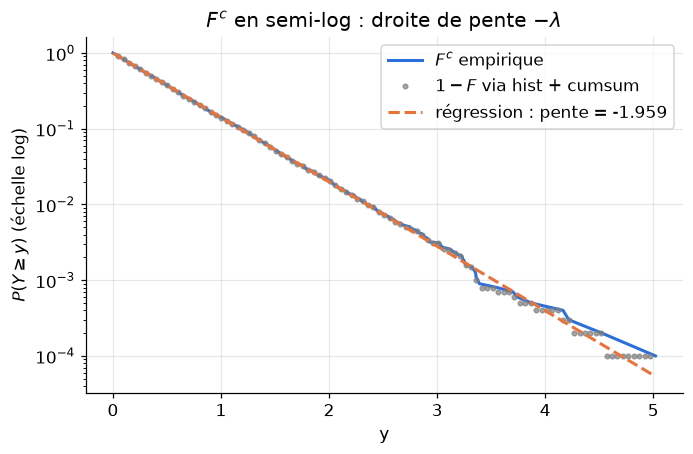

In [5]:
bords, F_hist = repartition_histogramme(Y, bins=100)        # hist + cumsum
y_tri, Fc = repartition_complementaire(Y)                   # F^c empirique exacte
pente, ordonnee = pente_semilog(Y, quantile_max=0.99)        # régression sur 99 % des points

fig, ax = plt.subplots()
ax.semilogy(y_tri, Fc, color=BLEU, lw=2, label=r"$F^c$ empirique")
ax.semilogy(bords[:-1], 1 - F_hist[:-1], "o", ms=3, color="gray", alpha=0.7, label=r"$1-F$ via hist + cumsum")
ax.semilogy(y_tri, np.exp(ordonnee + pente * y_tri), "--", color=ORANGE, lw=2,
            label=rf"régression : pente = {pente:.3f}")
ax.set(xlabel="y", ylabel=r"$P(Y \geq y)$ (échelle log)", title=r"$F^c$ en semi-log : droite de pente $-\lambda$")
ax.legend()
sauver(fig, FIG / "s11_Fc_semilog.png")
print(f"pente estimée = {pente:.4f}   (attendu -λ = {-LAM})   erreur relative = {abs(pente + LAM)/LAM:.1%}")
resultats["exp"]["pente"] = pente

**Commentaire.** Les points s'alignent bien sur une droite : la décroissance est exponentielle et la pente mesurée est voisine de $-\lambda = -2$.
Dans la queue ($y$ grand), il reste très peu de tirages : $F^c$ empirique devient une marche d'escalier bruitée (la dernière valeur vaut $1/T$). C'est pourquoi on ajuste la droite sur la partie bien peuplée (99 % des points).

In [6]:
_ = RESULTATS.write_text(json.dumps(resultats, indent=2))  # _ = : n'affiche pas le nombre de caractères écrits